We decided to work with CIFAR-10 for the Project.
1. load data
- Load training and test sets
- Verify shapes
- Verify data types
- Verify labels
2. EDA:
  - print dataset shape & pixel range
  - print classes (class imbalance)
  - check for duplicates
  - check for blanks
  - Visualization:
    - random (32 images)
    - random images per class
3. Data Preprocessing
  - Normalizing values
  - One-hot encoding (to_categorical())
  - Split the data
    Training set
    Validation set
    Test set
    Use stratification if appropriate ?
  - Data augmentation
    Examples:
    Horizontal flip
    Small rotations
    Zoom
    Width/height shifts
    (Apply only to the training set.)
 4. Build a CNN from Scratch

In [84]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [85]:
import numpy as np

In [86]:
x_temp = np.load('/content/drive/MyDrive/cifar10_data/x_train.npy')
y_temp = np.load('/content/drive/MyDrive/cifar10_data/y_train.npy')
x_test = np.load('/content/drive/MyDrive/cifar10_data/x_test.npy')
y_test = np.load('/content/drive/MyDrive/cifar10_data/y_test.npy')

In [87]:
import tensorflow as tf

x_temp = tf.image.resize(x_temp, [32, 32]).numpy()
x_test  = tf.image.resize(x_test,  [32, 32]).numpy()

np.save('/content/drive/MyDrive/cifar10_data/x_train.npy', x_temp)
np.save('/content/drive/MyDrive/cifar10_data/x_test.npy',  x_test)

print("Done! Shapes:")
print("x_train:", x_temp.shape)
print("x_test: ", x_test.shape)

Done! Shapes:
x_train: (50000, 32, 32, 3)
x_test:  (10000, 32, 32, 3)


In [88]:
print("x_temp:", x_temp.shape)
print("y_temp:", y_temp.shape)
print("x_test :", x_test.shape)
print("y_test :", y_test.shape)

x_temp: (50000, 32, 32, 3)
y_temp: (50000, 10)
x_test : (10000, 32, 32, 3)
y_test : (10000, 10)


In [89]:
import numpy as np

classes = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
labels, counts = np.unique(np.argmax(y_temp, axis=1), return_counts=True)

for l, c in zip(labels, counts):
    print(f"{classes[int(l)]}: {c}")

airplane: 5000
automobile: 5000
bird: 5000
cat: 5000
deer: 5000
dog: 5000
frog: 5000
horse: 5000
ship: 5000
truck: 5000


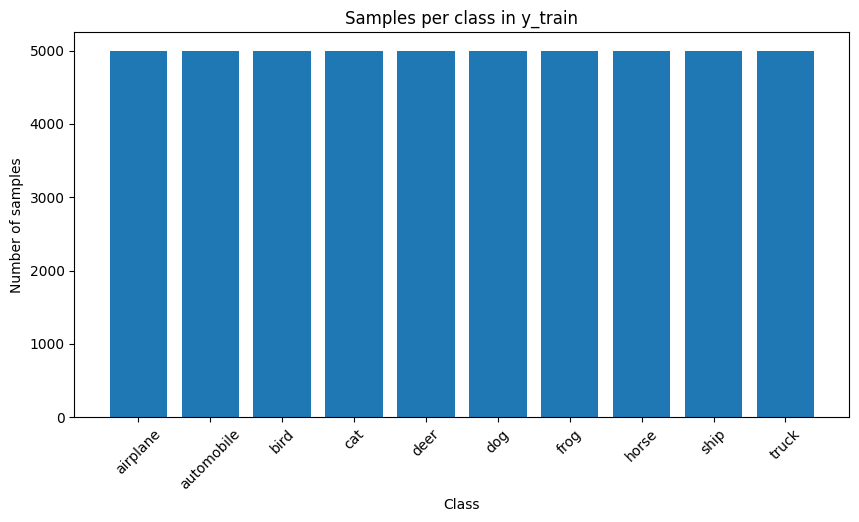

In [90]:
import matplotlib.pyplot as plt

labels, counts = np.unique(np.argmax(y_temp, axis=1), return_counts=True)

plt.figure(figsize=(10,5))
plt.bar([classes[int(l)] for l in labels], counts)
plt.xlabel("Class")
plt.ylabel("Number of samples")
plt.title("Samples per class in y_train")
plt.xticks(rotation=45)
plt.show()

In [91]:
# Basic info & pixel range
print("=== Dataset shapes ===")
print(f"x_temp: {x_temp.shape}")
print(f"y_temp: {y_temp.shape}")
print(f"x_test:  {x_test.shape}")
print(f"y_test:  {y_test.shape}")

print("\n=== Pixel values ===")
print(f"Min: {x_temp.min()}")
print(f"Max: {x_temp.max()}")
print(f"Mean: {x_temp.mean():.4f}")

=== Dataset shapes ===
x_temp: (50000, 32, 32, 3)
y_temp: (50000, 10)
x_test:  (10000, 32, 32, 3)
y_test:  (10000, 10)

=== Pixel values ===
Min: 0.0
Max: 1.0
Mean: 0.4734


In [92]:
# Duplicates?

# x_flat = x_temp.reshape(len(x_temp), -1)
# unique = np.unique(x_flat, axis=0)
# print(f"Total images:  {len(x_temp)}")
# print(f"Unique images: {len(unique)}")
# print(f"Duplicates:    {len(x_temp) - len(unique)}")


In [93]:
# blank images? if all pixels same value -> is blank

# blank = [i for i in range(len(x_temp)) if x_temp[i].std() == 0]
# print(f"Blank/corrupt images: {len(blank)}")

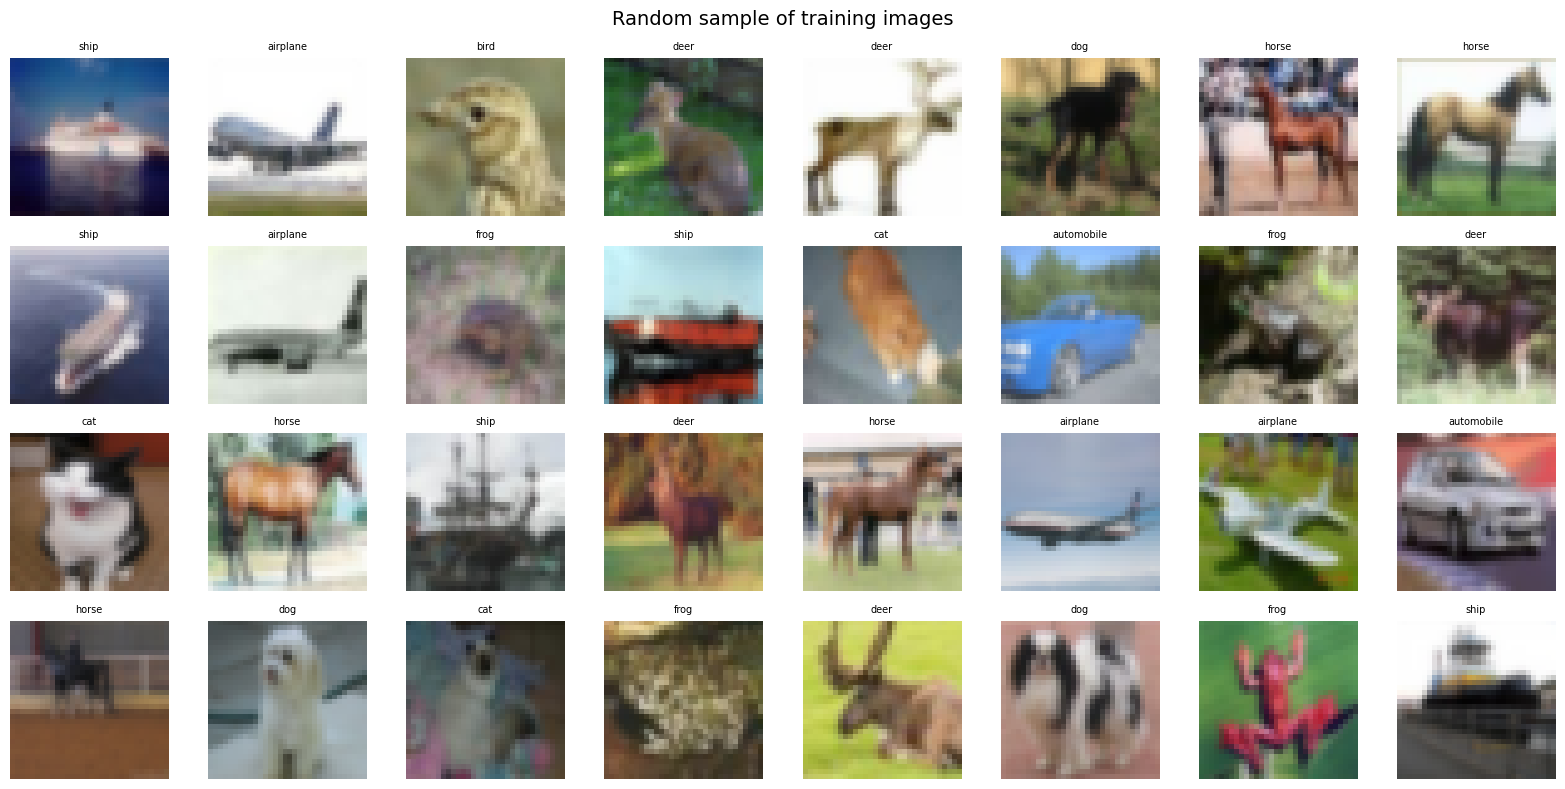

In [94]:
# random plot of images

fig, axes = plt.subplots(4, 8, figsize=(16, 8))
axes = axes.flatten()

random_indices = np.random.choice(len(x_temp), 32, replace=False)

for i, idx in enumerate(random_indices):
    axes[i].imshow(x_temp[idx])
    axes[i].set_title(classes[np.argmax(y_temp[idx])], fontsize=7)
    axes[i].axis('off')

plt.suptitle('Random sample of training images', fontsize=14)
plt.tight_layout()
plt.show()

In [95]:
print(y_temp.shape)
print(y_temp[0])

(50000, 10)
[0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]


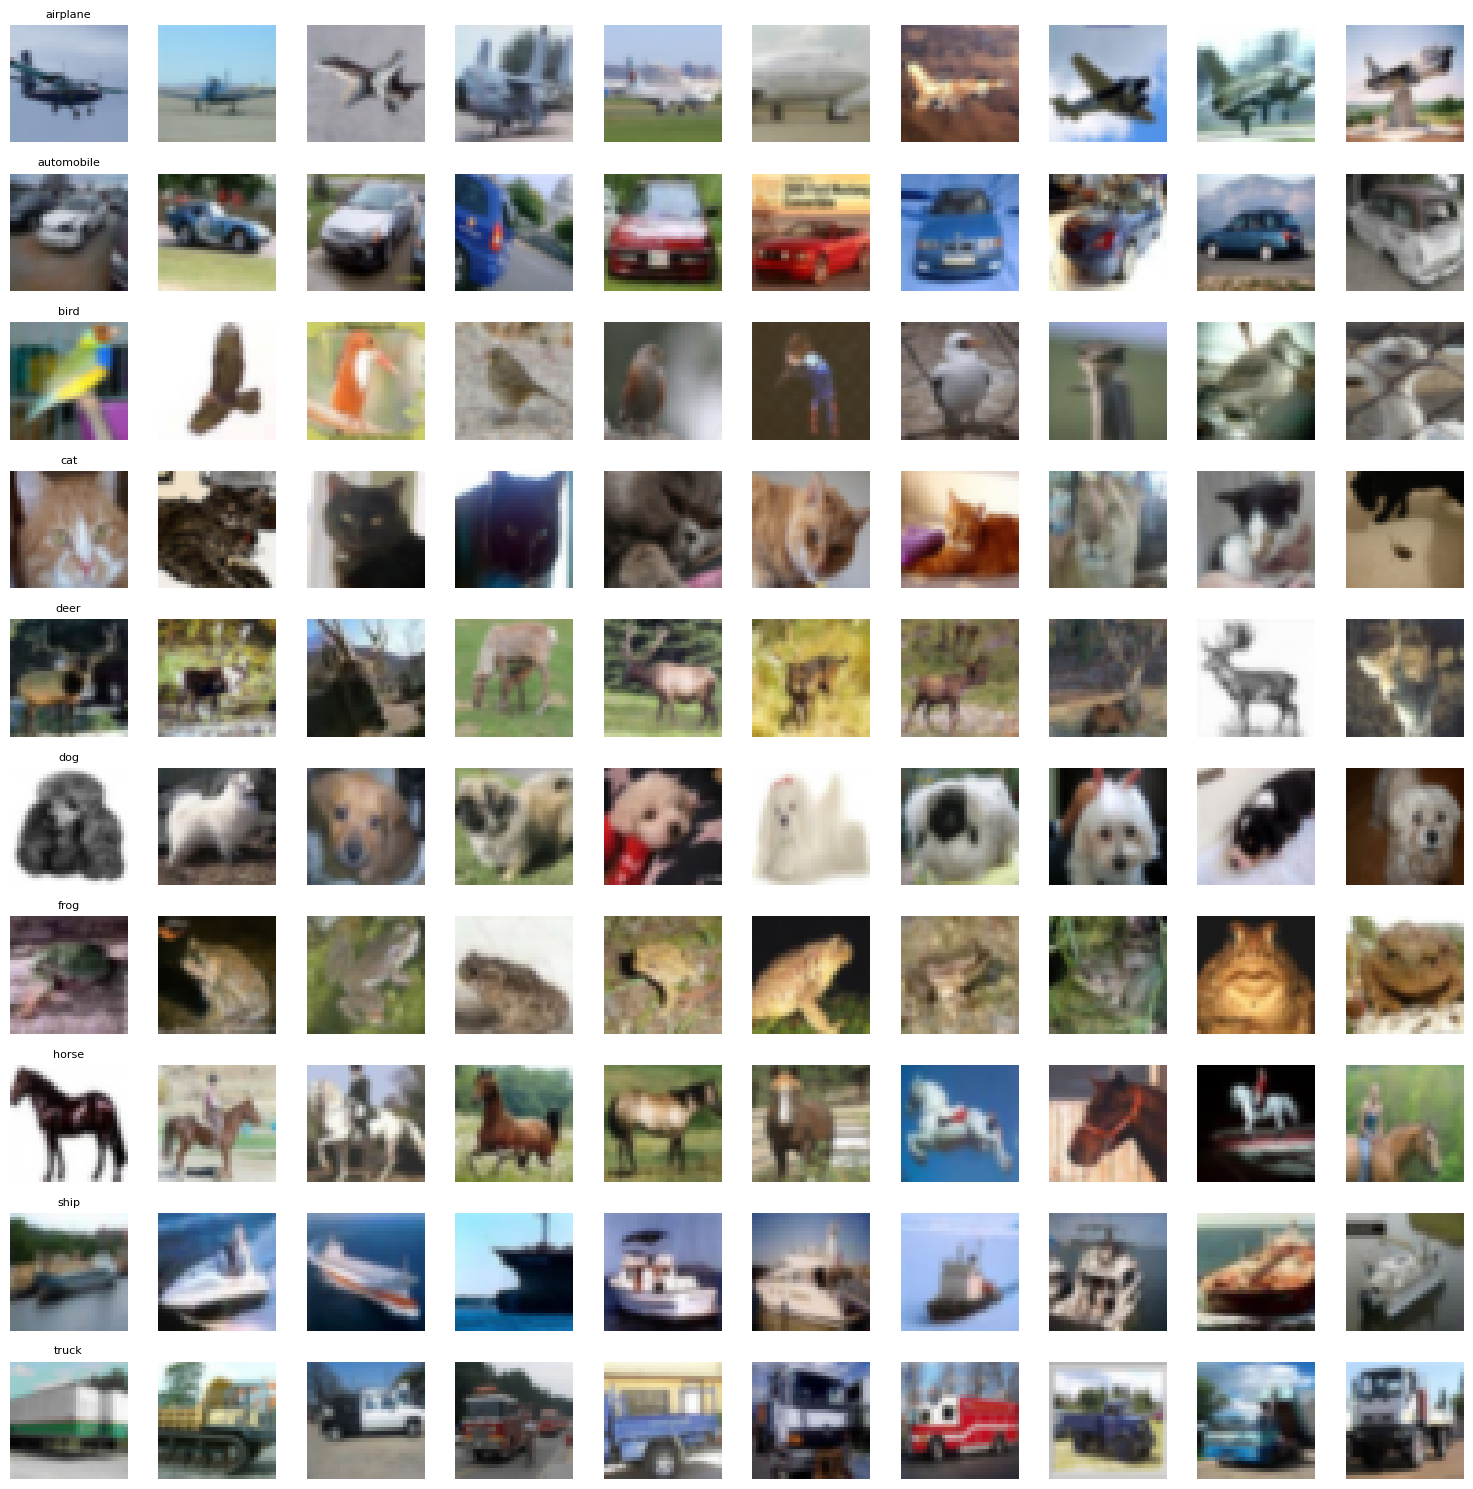

In [96]:
# Visualise samples/class

fig, axes = plt.subplots(10, 10, figsize=(15, 15))

y_temp_labels = np.argmax(y_temp, axis=1)  # recover integer labels

for class_idx in range(10):
    class_indices = np.where(y_temp_labels == class_idx)[0]
    sample_indices = np.random.choice(class_indices, 10, replace=False)
    for col, img_idx in enumerate(sample_indices):
        axes[class_idx, col].imshow(x_temp[img_idx])
        axes[class_idx, col].axis('off')
        if col == 0:
            axes[class_idx, col].set_title(classes[class_idx], fontsize=8)

plt.tight_layout()
plt.show()

In [97]:
from sklearn.model_selection import train_test_split

# x_train, y_train from CIFAR-10's original train set
x_train, x_val, y_train, y_val = train_test_split(
    x_temp, y_temp,
    test_size=0.18,
    stratify=y_temp.argmax(axis=1),    # keep class balance
    random_state=42
)

print("x_train:", x_train.shape)
print("y_train:", y_train.shape)
print("x_val  :", x_val.shape)
print("y_val  :", y_val.shape)

x_train: (41000, 32, 32, 3)
y_train: (41000, 10)
x_val  : (9000, 32, 32, 3)
y_val  : (9000, 10)


In [98]:
from tensorflow.keras.utils import to_categorical


x_train = x_train.astype('float32') 
x_test  = x_test.astype('float32') 

x_val = x_val.astype('float32') 
# y_val = to_categorical(y_val, num_classes=10)

# y_train = to_categorical(y_train, num_classes=10)
# y_test  = to_categorical(y_test, num_classes=10)

print("x_train shape:", x_train.shape)
# print("y_train shape:", y_train.shape)
print("x_test shape: ", x_test.shape)
# print("y_test shape: ", y_test.shape)
print("x_val shape:  ", x_val.shape)
# print("y_val shape:  ", y_val.shape)
print("\n=== Pixel values ===")
print(f"Min: {x_train.min()}")
print(f"Max: {x_train.max()}")
print(f"Mean: {x_train.mean():.4f}")
print(type(x_train))


x_train shape: (41000, 32, 32, 3)
x_test shape:  (10000, 32, 32, 3)
x_val shape:   (9000, 32, 32, 3)

=== Pixel values ===
Min: 0.0
Max: 1.0
Mean: 0.4735
<class 'numpy.ndarray'>


In [99]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

model = Sequential([
    
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    BatchNormalization(),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.1),

    
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.2),

    
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.2),

    Flatten(),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),
    Dense(10, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_35 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_45          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_46          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_47          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_48          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_39 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_49          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_40 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_50          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_51          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 569,898 (2.17 MB)

 Trainable params: 568,490 (2.17 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [100]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Learning rate:", model.optimizer.learning_rate.numpy())

Learning rate: 1e-04


In [101]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)

history = model.fit(
    x_train, y_train,
    epochs=40,
    batch_size=32,
    validation_data=(x_val, y_val),
    callbacks=[early_stop, lr_scheduler]
)

end = time.time()
print(f"\nTraining time: {(end - start)/60:.1f} minutes")
print(f"Stopped at epoch: {len(history.history['accuracy'])}")
print(f"Final train accuracy:      {history.history['accuracy'][-1]:.4f}")
print(f"Final validation accuracy: {history.history['val_accuracy'][-1]:.4f}")

Epoch 1/40
1282/1282 ━━━━━━━━━━━━━━━━━━━━ 35s 15ms/step - accuracy: 0.2546 - loss: 2.3743 - val_accuracy: 0.4083 - val_loss: 1.6065 - learning_rate: 1.0000e-04
Epoch 2/40
1282/1282 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.3595 - loss: 1.8619 - val_accuracy: 0.4897 - val_loss: 1.3878 - learning_rate: 1.0000e-04
Epoch 3/40
1282/1282 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.4272 - loss: 1.6201 - val_accuracy: 0.5269 - val_loss: 1.2975 - learning_rate: 1.0000e-04
Epoch 4/40
1282/1282 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.4771 - loss: 1.4645 - val_accuracy: 0.5773 - val_loss: 1.1668 - learning_rate: 1.0000e-04
Epoch 5/40
1282/1282 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5261 - loss: 1.3306 - val_accuracy: 0.6161 - val_loss: 1.0677 - learning_rate: 1.0000e-04
Epoch 6/40
1282/1282 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5657 - loss: 1.2196 - val_accuracy: 0.6421 - val_loss: 1.0021 - learning_rate: 1.0000e-04
Epoch 7/40
1282/1282 ━━━━━━━━━━━━━━━━━━━━ 9s 7

In [102]:
model.save("Model_cf_9.keras")

In [103]:
from google.colab import drive
drive.mount('/content/drive')

model.save('/content/drive/MyDrive/Model_cf_9.keras')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
